      MODEL PERFORMANCE EVALUATION           
R² Score : 0.91
RMSE     : 0.057 t/ha
MAE      : 0.051 t/ha

Feature Importances:
Fertilizer_Usage      0.433669
Solar_Radiation_MJ    0.278248
Temp_C                0.173391
Precip_mm             0.114693
dtype: float64


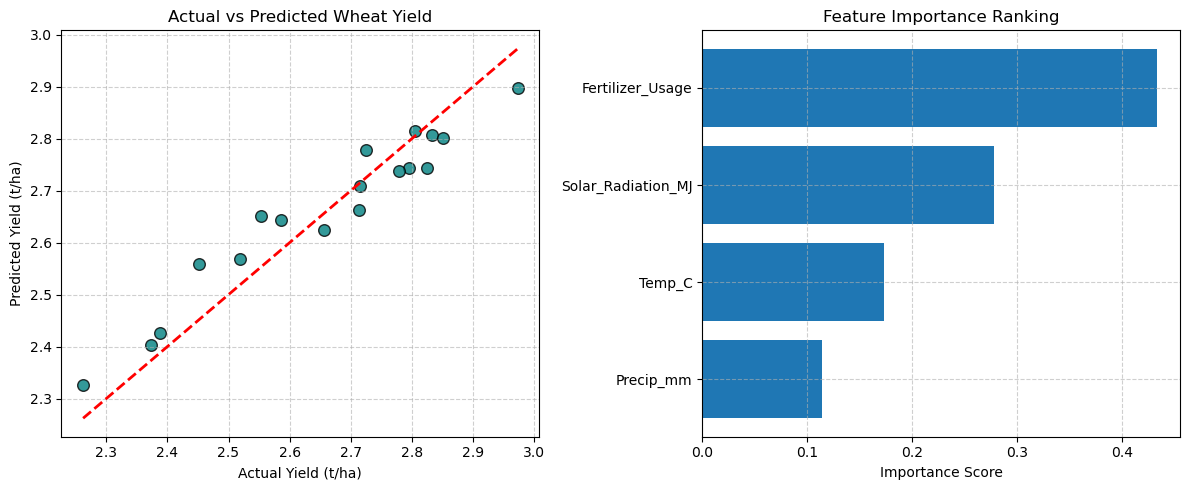

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Load Data
fao_file = "FAOSTAT_data_en_8-13-2026 (1).csv"
nasa_file = "nasa_power_punjab_2000_2019.csv"
wb_file = "worldbank_fertilizer.csv"

# Preprocess FAOSTAT
df_fao = pd.read_csv(fao_file)
df_fao_yield = df_fao[df_fao["Element"] == "Yield"].copy()
df_fao_yield["Yield_tha"] = df_fao_yield["Value"] / 1000.0
yield_df = df_fao_yield[["Year", "Yield_tha"]]

# Preprocess NASA POWER
df_nasa = pd.read_csv(nasa_file)
df_nasa["Date"] = pd.to_datetime(df_nasa["Date"])
df_nasa["Year"] = df_nasa["Date"].dt.year
nasa_annual = (
    df_nasa.groupby("Year")
    .agg(
        {
            "Temp_C": "mean",
            "Precip_mm": "sum",
            "Solar_Radiation_MJ": "mean",
        }
    )
    .reset_index()
)

# Preprocess World Bank
df_wb = pd.read_csv(wb_file)

# 2. Merge Datasets
df_merged = yield_df.merge(nasa_annual, on="Year", how="inner").merge(
    df_wb, on="Year", how="inner"
)

# 3. Define Features and Target
features = ["Temp_C", "Precip_mm", "Solar_Radiation_MJ", "Fertilizer_Usage"]
target = "Yield_tha"

X = df_merged[features]
y = df_merged[target]

# 4. Train Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X, y)
y_pred = rf_model.predict(X)

# 5. Evaluate Metrics
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
mae = mean_absolute_error(y, y_pred)

print("=" * 45)
print("      MODEL PERFORMANCE EVALUATION           ")
print("=" * 45)
print(f"R² Score : {r2:.2f}")
print(f"RMSE     : {rmse:.3f} t/ha")
print(f"MAE      : {mae:.3f} t/ha")
print("=" * 45)

# 6. Feature Importances
importances = pd.Series(
    rf_model.feature_importances_, index=features
).sort_values(ascending=False)
print("\nFeature Importances:")
print(importances)

# 7. Render Plots Inline
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Actual vs Predicted Plot
ax1.scatter(y, y_pred, color="teal", alpha=0.8, edgecolors="k", s=70)
ax1.plot([y.min(), y.max()], [y.min(), y.max()], "r--", lw=2)
ax1.set_xlabel("Actual Yield (t/ha)")
ax1.set_ylabel("Predicted Yield (t/ha)")
ax1.set_title("Actual vs Predicted Wheat Yield")
ax1.grid(True, linestyle="--", alpha=0.6)

# Feature Importance Plot
y_pos = np.arange(len(importances))
ax2.barh(y_pos, importances.values[::-1], color="#1f77b4")
ax2.set_yticks(y_pos)
ax2.set_yticklabels(importances.index[::-1])
ax2.set_xlabel("Importance Score")
ax2.set_title("Feature Importance Ranking")
ax2.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()